<a href="https://colab.research.google.com/github/mohdrizwan11/Leetcode-Solutions/blob/main/Handwritten_Digit_Recognition.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [1]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
from sklearn.model_selection import train_test_split

# Load Dataset

In [3]:
# Load MNIST
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

print("Original Training Shape:", x_train.shape)
print("Original Test Shape:", x_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Original Training Shape: (60000, 28, 28)
Original Test Shape: (10000, 28, 28)


# Preprocess Data

In [5]:
#Normalize pixels (0–255 → 0–1)
x_train = x_train / 255.0
x_test = x_test / 255.0

In [7]:
#Flatten images (28×28 → 784)
x_train = x_train.reshape(-1, 28*28)
x_test = x_test.reshape(-1, 28*28)

In [8]:
#Create Validation Set
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train,
    test_size=10000,
    random_state=42
)

print("Train:", x_train.shape)
print("Validation:", x_val.shape)
print("Test:", x_test.shape)

Train: (50000, 784)
Validation: (10000, 784)
Test: (10000, 784)


# Create Model


In [24]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras import regularizers

layer_1 = Dense(
    units=25,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001),
    input_shape=(784,)
)

layer_2 = Dense(
    units=15,
    activation='relu',
    kernel_regularizer=regularizers.l2(0.001)
)

layer_3 = Dense(
    units=10,
    activation='softmax'
)

model = Sequential([layer_1, layer_2, layer_3])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_9 (Dense)                 │ (None, 25)             │        19,625 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │           160 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,175 (78.81 KB)

 Trainable params: 20,175 (78.81 KB)

 Non-trainable params: 0 (0.00 B)

# Compile Model

In [25]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Model

In [26]:
history = model.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=32
)

Epoch 1/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7466 - loss: 0.8866 - val_accuracy: 0.9268 - val_loss: 0.3380
Epoch 2/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9325 - loss: 0.3241 - val_accuracy: 0.9442 - val_loss: 0.2842
Epoch 3/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9437 - loss: 0.2746 - val_accuracy: 0.9465 - val_loss: 0.2672
Epoch 4/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9517 - loss: 0.2535 - val_accuracy: 0.9485 - val_loss: 0.2550
Epoch 5/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9541 - loss: 0.2428 - val_accuracy: 0.9465 - val_loss: 0.2605
Epoch 6/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9580 - loss: 0.2282 - val_accuracy: 0.9526 - val_loss: 0.2452
Epoch 7/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9590 - loss: 0.2194 - val_accuracy: 0.9556 - val_loss: 0.2345
Epoch 8/50
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9607 - loss: 0.2128 - 

# Evaluate Model

In [27]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9612 - loss: 0.1910
Test Accuracy: 0.9656999707221985


In [14]:
#Compare Training vs Validation Accuracy
history.history['accuracy'][-1]
history.history['val_accuracy'][-1]

0.964900016784668

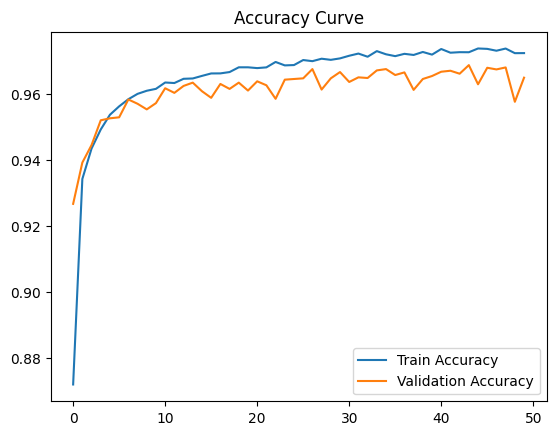

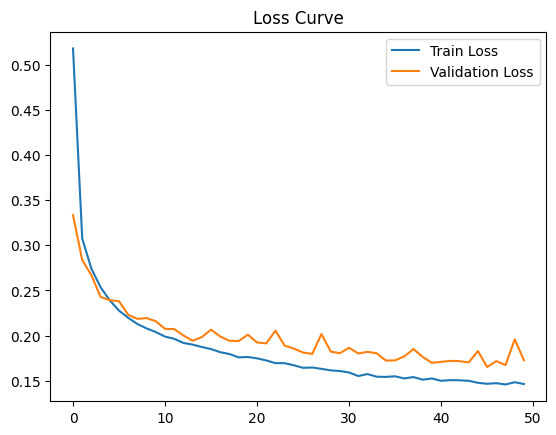

In [15]:
#Learning Curves
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title("Accuracy Curve")
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.show()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


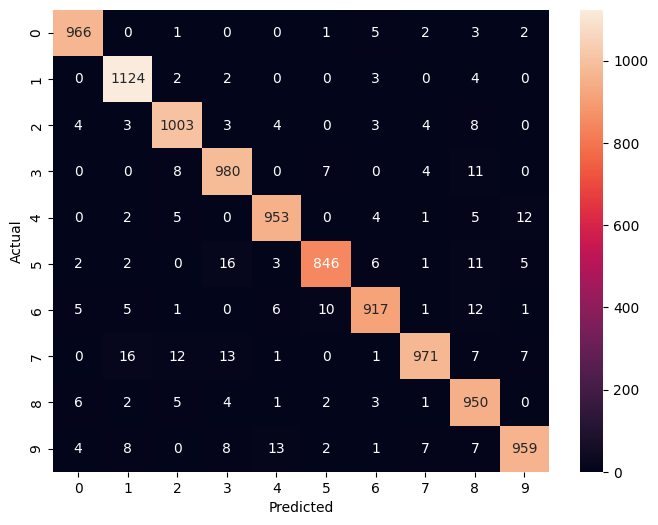

In [16]:
#Confusion Matrix
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_pred = np.argmax(model.predict(x_test), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Get Predictions

In [28]:

import numpy as np

predictions = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


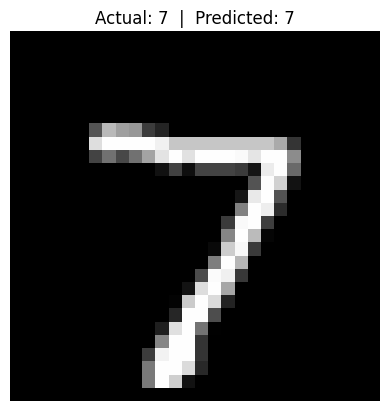

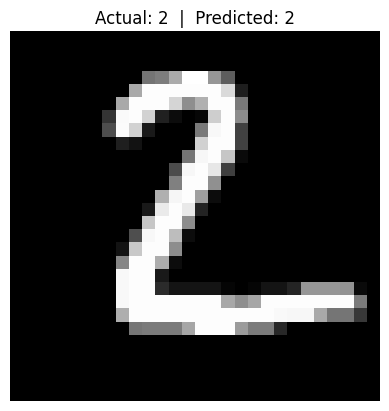

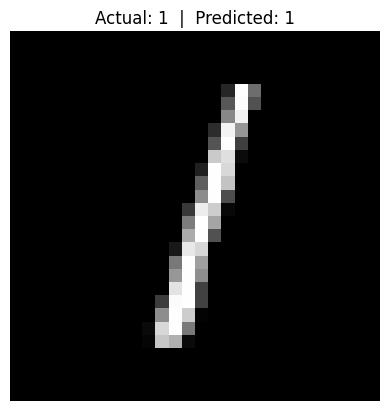

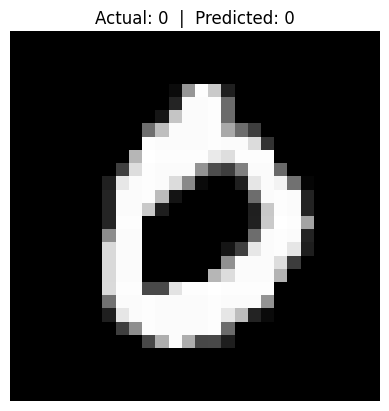

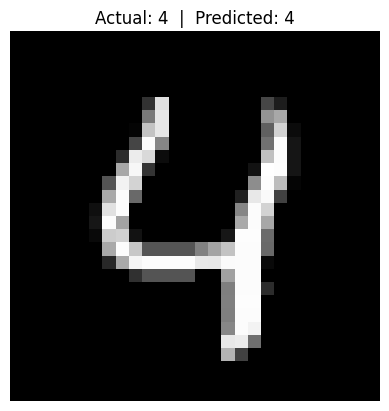

In [29]:
import matplotlib.pyplot as plt

def show_prediction(index):
    plt.imshow(x_test[index].reshape(28,28), cmap='gray')
    plt.title(f"Actual: {y_test[index]}  |  Predicted: {predicted_labels[index]}")
    plt.axis('off')
    plt.show()

# Try a few examples
for i in range(5):
    show_prediction(i)